In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (8).zip to archive (8).zip


In [3]:
import zipfile

zip_path = "archive (8).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
import os
os.listdir("dataset")

['BAJAJFINSV.csv',
 'BAJAJ-AUTO.csv',
 'EICHERMOT.csv',
 'BAJFINANCE.csv',
 'stock_metadata.csv',
 'IOC.csv',
 'INFRATEL.csv',
 'JSWSTEEL.csv',
 'SUNPHARMA.csv',
 'NTPC.csv',
 'GRASIM.csv',
 'KOTAKBANK.csv',
 'MM.csv',
 'HINDUNILVR.csv',
 'ASIANPAINT.csv',
 'TITAN.csv',
 'ULTRACEMCO.csv',
 'NESTLEIND.csv',
 'TATASTEEL.csv',
 'UPL.csv',
 'AXISBANK.csv',
 'GAIL.csv',
 'TECHM.csv',
 'MARUTI.csv',
 'INDUSINDBK.csv',
 'HINDALCO.csv',
 'TATAMOTORS.csv',
 'CIPLA.csv',
 'ICICIBANK.csv',
 'INFY.csv',
 'HDFC.csv',
 'ONGC.csv',
 'COALINDIA.csv',
 'ITC.csv',
 'HCLTECH.csv',
 'NIFTY50_all.csv',
 'BHARTIARTL.csv',
 'LT.csv',
 'ADANIPORTS.csv',
 'BRITANNIA.csv',
 'POWERGRID.csv',
 'VEDL.csv',
 'SBIN.csv',
 'DRREDDY.csv',
 'HDFCBANK.csv',
 'RELIANCE.csv',
 'HEROMOTOCO.csv',
 'TCS.csv',
 'SHREECEM.csv',
 'BPCL.csv',
 'WIPRO.csv',
 'ZEEL.csv']

In [34]:
df = pd.read_csv('dataset/RELIANCE.csv')

In [35]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [36]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [37]:
df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [38]:
df.dropna(inplace=True)

In [39]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
2850,2011-06-01,RELIANCE,EQ,951.85,952.00,958.65,943.65,947.5,946.80,947.83,1838452,1.742538e+14,58630.0,901415.0,0.4903
2851,2011-06-02,RELIANCE,EQ,946.80,936.55,954.70,936.55,952.5,951.05,947.09,2152963,2.039039e+14,63061.0,1066759.0,0.4955
2852,2011-06-03,RELIANCE,EQ,951.05,960.50,967.00,931.50,936.0,934.60,951.69,4368279,4.157238e+14,128784.0,1035791.0,0.2371
2853,2011-06-06,RELIANCE,EQ,934.60,934.65,940.80,928.15,938.6,937.75,935.29,1405741,1.314771e+14,43384.0,476631.0,0.3391
2854,2011-06-07,RELIANCE,EQ,937.75,933.55,960.00,933.55,959.6,958.25,950.55,4025919,3.826839e+14,88703.0,2424958.0,0.6023


In [53]:
X = df[['Open','High','Low','Volume']]
y = df['Close']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [55]:
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

In [56]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
).ravel()

In [57]:
model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma='scale'
)

model.fit(X_train, y_train_scaled)

SVR(C=100)

In [58]:
pred_scaled = model.predict(X_test)

pred = scaler_y.inverse_transform(
    pred_scaled.reshape(-1,1)
).flatten()

In [59]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE =", rmse)
print("R2 =", r2)

RMSE = 14.447604366216773
R2 = 0.9982365733947992


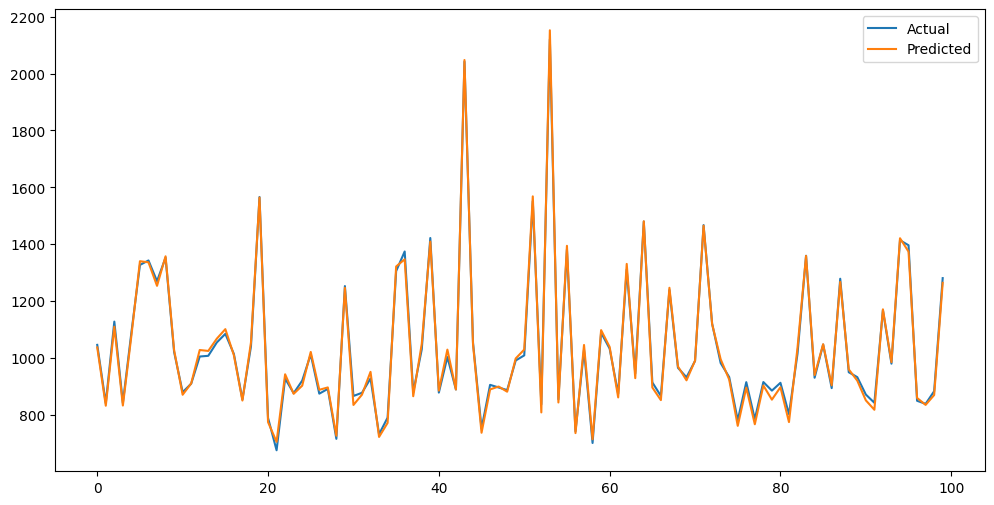

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(pred[:100], label='Predicted')

plt.legend()
plt.show()

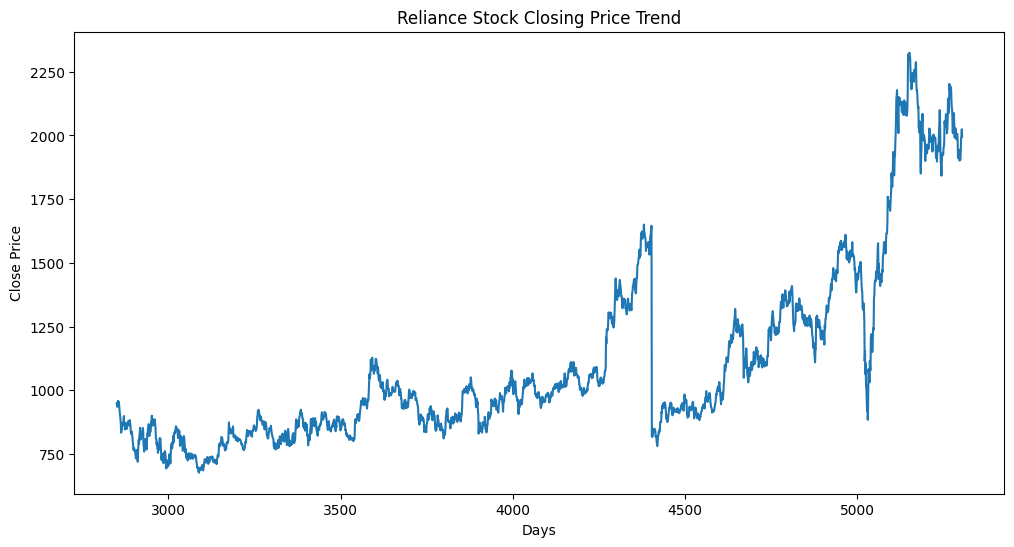

In [61]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'])

plt.title('Reliance Stock Closing Price Trend')
plt.xlabel('Days')
plt.ylabel('Close Price')

plt.show()

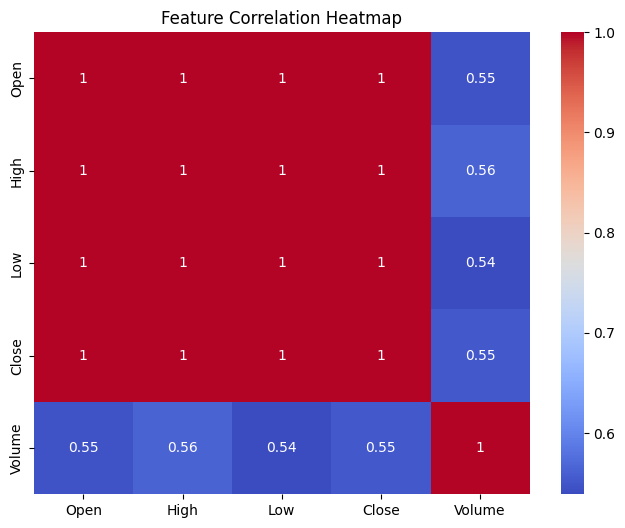

In [62]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Open','High','Low','Close','Volume']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

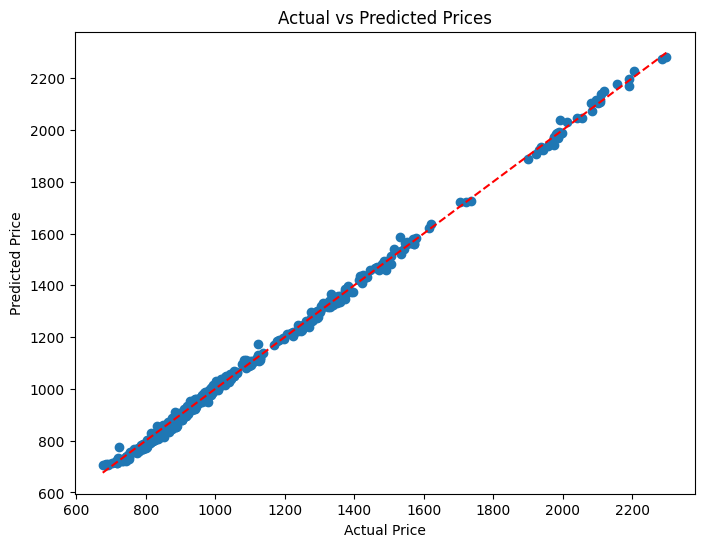

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

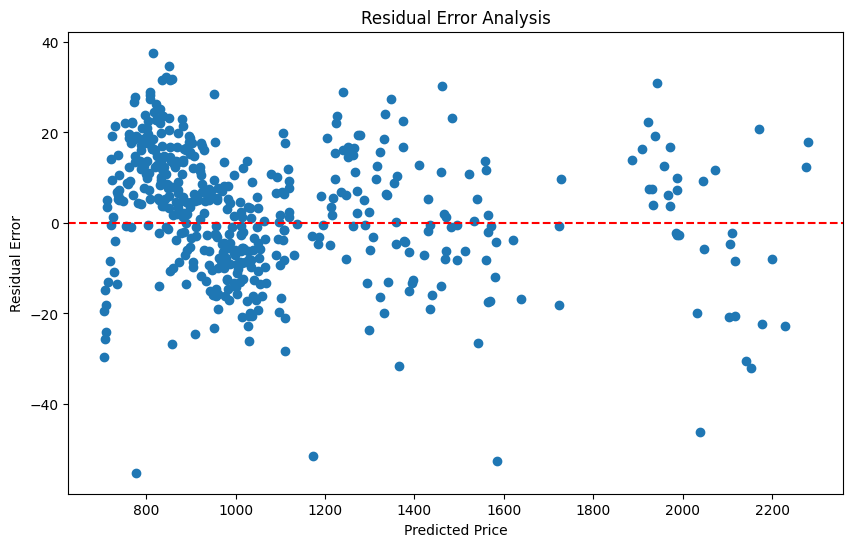

In [64]:
residuals = y_test - pred

plt.figure(figsize=(10,6))

plt.scatter(pred, residuals)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")

plt.title("Residual Error Analysis")

plt.show()

In [65]:
residuals = y_test - pred

print("Mean Residual =", residuals.mean())
print("Min Residual =", residuals.min())
print("Max Residual =", residuals.max())
print("Std Residual =", residuals.std())

Mean Residual = 2.7829758991352045
Min Residual = -55.17761903330336
Max Residual = 37.60826838516209
Std Residual = 14.191464403254397


The Support Vector Regression (SVR) model achieved an R² score of 0.98, indicating excellent predictive performance. The predicted stock prices closely matched the actual prices, demonstrating that the model successfully captured the underlying patterns in the Reliance stock dataset. The low RMSE and high R² score suggest that SVR with the RBF kernel is highly effective for this regression task.